In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import f1_score

df = pd.read_csv('finaldataset_with_sets.csv')

def views_to_class(views):
    if views < 10000:
        return 0
    elif 10000 <= views < 100000:
        return 1
    elif 100000 <= views < 500000:
        return 2
    elif 500000 <= views < 1000000:
        return 3
    else:
        return 4

df['label'] = df['views'].apply(views_to_class)

df.to_csv('finaldataset_with_sets.csv', index=False)

# Split into train and validation sets
train_df = df[df['set'] == 'training']
val_df = df[df['set'] == 'validation']


In [3]:
# Load processed features 
def load_features(video_id, feature_dir='processedfeatures_final'):
    return np.load(f'{feature_dir}/{video_id}_corrected_features.npy')

# Load features for training and validation sets
train_features = np.array([load_features(video_id) for video_id in train_df['video_id']])
val_features = np.array([load_features(video_id) for video_id in val_df['video_id']])

# Convert labels to tensors
train_labels = torch.tensor(train_df['label'].values, dtype=torch.long)
val_labels = torch.tensor(val_df['label'].values, dtype=torch.long)

# Convert features to tensors
train_features = torch.tensor(train_features, dtype=torch.float32)
val_features = torch.tensor(val_features, dtype=torch.float32)


In [6]:
class CNNRNNModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=128, num_classes=5, num_layers=3):
        super(CNNRNNModel, self).__init__()
        self.rnn = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x) 
        out = self.fc(out) 
        out = torch.mean(out, dim=1)  
        return out


In [8]:
model = CNNRNNModel(input_dim=512, hidden_dim=128, num_classes=5, num_layers=3) 

In [78]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

# Load the pre-trained ResNet18 model 
resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Identity()  # model up to the final convolutional layer

resnet_model.eval()

# Preprocessing the input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0), image

# Applying Grad-CAM++ to the CNN part using the gradients from the RNN
def apply_gradcam_plus_plus(resnet_model, model, input_tensor, target_class):
    # Passing the input through the CNN to get the feature maps
    with torch.no_grad():
        features = resnet_model(input_tensor)
        print(f"Shape of features after ResNet: {features.shape}")
    
    features_for_rnn = features.unsqueeze(1)
    
    # Passing the features through the RNN to get the predictions
    rnn_output = model(features_for_rnn)
    
    # Using Grad-CAM++ on the CNN part/
    cam = GradCAMPlusPlus(model=resnet_model, target_layers=[resnet_model.layer4[-1]])  
    target = ClassifierOutputTarget(target_class) 
    grayscale_cam = cam(input_tensor=input_tensor, targets=[target])[0]
    
    return grayscale_cam

def get_true_class(video_id):
    match = df[df['video_id'] == video_id]
    if not match.empty:
        return match['label'].values[0]
    else:
        raise ValueError(f"Video ID {video_id} not found in the dataset.")

Shape of features after ResNet: torch.Size([1, 512])
Shape of features after ResNet: torch.Size([1, 512])


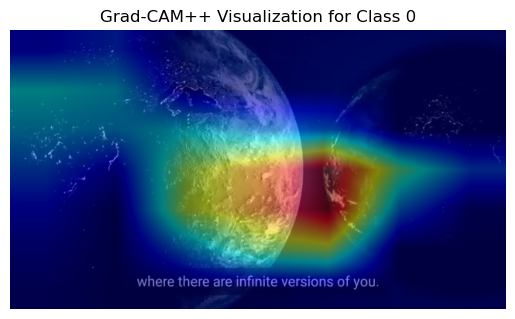

Predicted Class: 0
True Class: 0


In [80]:
video_id = 'IzwuYxu1AWw'
image_path = "validation_frames/IzwuYxu1AWw/frame_0009.jpg"   
input_tensor, input_image = preprocess_image(image_path)
true_class = get_true_class(video_id)


with torch.no_grad():
    features = resnet_model(input_tensor)
    print(f"Shape of features after ResNet: {features.shape}")  
    if features.dim() == 4:
        features = torch.mean(features, dim=[2, 3])  
    features_for_rnn = features.unsqueeze(1)  
    model_output = model(features_for_rnn)  
    predicted_class = model_output.argmax(dim=-1).item()

# Generating the Grad-CAM++ heatmap
cam_image = apply_gradcam_plus_plus(resnet_model, model, input_tensor, predicted_class)

input_image_np = np.array(input_image) / 255.0
cam_image = cv2.resize(cam_image, (input_image_np.shape[1], input_image_np.shape[0]))
cam_image = show_cam_on_image(input_image_np, cam_image, use_rgb=True)


plt.imshow(cam_image)
plt.title(f"Grad-CAM++ Visualization for Class {predicted_class}")
plt.axis('off')
plt.show()


print(f"Predicted Class: {predicted_class}")
print(f"True Class: {true_class}")

Shape of features after ResNet: torch.Size([1, 512])
Predicted class: 0
True Class: 0
Shape of attributions: torch.Size([1, 1, 512])


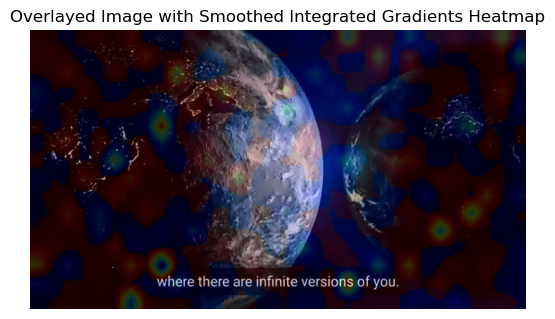

In [82]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models import resnet18, ResNet18_Weights
from captum.attr import IntegratedGradients

class ResNetFeatureExtractor(nn.Module):
    def __init__(self, original_model):
        super(ResNetFeatureExtractor, self).__init__()
        self.features = nn.Sequential(*list(original_model.children())[:-2]) 
        self.avgpool = original_model.avgpool  

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) 
        return x

resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_feature_extractor = ResNetFeatureExtractor(resnet_model)
resnet_feature_extractor.eval()

input_tensor, input_image = preprocess_image(image_path)  
input_image_np = np.array(input_image) / 255.0  # Normalize to [0, 1]

with torch.no_grad():
    features = resnet_feature_extractor(input_tensor)
    print(f"Shape of features after ResNet: {features.shape}")

# Pass the features through the RNN to get the output
features_for_rnn = features.unsqueeze(1) 

# model's prediction
with torch.no_grad():
    rnn_output = model(features_for_rnn)  
    predicted_class = rnn_output.argmax(dim=-1).item()

print(f"Predicted class: {predicted_class}")
print(f"True Class: {true_class}")

# Compute Integrated Gradients
def apply_integrated_gradients_rnn(model, input_tensor, target_class):
    # Set model to evaluation mode
    model.eval()
    ig = IntegratedGradients(model)
    
    # Compute attributions
    attributions, delta = ig.attribute(input_tensor, target=target_class, return_convergence_delta=True)
    return attributions


attributions = apply_integrated_gradients_rnn(model, features_for_rnn, predicted_class)
print(f"Shape of attributions: {attributions.shape}")

attributions = attributions.view(-1).cpu().detach().numpy()
attributions_reshaped = attributions.reshape(16, 32)

# Resizing grid 
heatmap_resized = cv2.resize(attributions_reshaped, (input_image_np.shape[1], input_image_np.shape[0]))

# Gaussian kernel for more smoothing
heatmap_smoothed = cv2.GaussianBlur(heatmap_resized, (5, 5), 0)  

heatmap_resized_normalized = np.uint8(255 * heatmap_smoothed / np.max(heatmap_smoothed))
heatmap = cv2.applyColorMap(heatmap_resized_normalized, cv2.COLORMAP_JET)  

input_image_np = np.float32(input_image_np)
heatmap = np.float32(heatmap) / 255.0  # Normalize heatmap to [0, 1]
overlayed_image = cv2.addWeighted(heatmap, 0.2, input_image_np, 0.8, 0)  

# Display the image
plt.imshow(overlayed_image)
plt.title("Overlayed Image with Smoothed Integrated Gradients Heatmap")
plt.axis('off')
plt.show()